In [ ]:
!pip install timm albumentations kagglehub

In [ ]:
import os
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, random_split

import timm
import kagglehub

from torchvision.datasets import ImageFolder
from torchvision import transforms

In [ ]:
path = kagglehub.dataset_download(
    "sovitrath/diabetic-retinopathy-224x224-2019-data"
)

print(path)

Using Colab cache for faster access to the 'diabetic-retinopathy-224x224-2019-data' dataset.
/kaggle/input/diabetic-retinopathy-224x224-2019-data


In [ ]:
DATASET_PATH = os.path.join(path, "colored_images")

print(os.listdir(DATASET_PATH))

['Mild', 'Proliferate_DR', 'Moderate', 'No_DR', 'Severe']


In [ ]:
train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

val_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [ ]:
full_dataset = ImageFolder(
    root=DATASET_PATH,
    transform=train_transform
)

print("Classes:", full_dataset.classes)
print("Total Images:", len(full_dataset))

Classes: ['Mild', 'Moderate', 'No_DR', 'Proliferate_DR', 'Severe']
Total Images: 3662


In [ ]:
train_size = int(0.8 * len(full_dataset))
val_size = len(full_dataset) - train_size

train_dataset, val_dataset = random_split(
    full_dataset,
    [train_size, val_size]
)

# Apply validation transform
val_dataset.dataset.transform = val_transform

In [ ]:
train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True,
    num_workers=2
)

val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=2
)

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [ ]:
model = timm.create_model(
    'swin_base_patch4_window7_224',
    pretrained=True,
    num_classes=5
)

model.to(device)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


SwinTransformer(
  (patch_embed): PatchEmbed(
    (proj): Conv2d(3, 128, kernel_size=(4, 4), stride=(4, 4))
    (norm): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
  )
  (layers): Sequential(
    (0): SwinTransformerStage(
      (downsample): Identity()
      (blocks): Sequential(
        (0): SwinTransformerBlock(
          (norm1): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
          (attn): WindowAttention(
            (qkv): Linear(in_features=128, out_features=384, bias=True)
            (attn_drop): Dropout(p=0.0, inplace=False)
            (proj): Linear(in_features=128, out_features=128, bias=True)
            (proj_drop): Dropout(p=0.0, inplace=False)
            (softmax): Softmax(dim=-1)
          )
          (drop_path1): Identity()
          (norm2): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
          (mlp): Mlp(
            (fc1): Linear(in_features=128, out_features=512, bias=True)
            (act): GELU(approximate='none')
            (

In [ ]:
for param in model.parameters():
    param.requires_grad = False

for param in model.head.parameters():
    param.requires_grad = True

In [ ]:
criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model.head.parameters(),
    lr=1e-3
)

In [ ]:
def train_one_epoch(model, loader):
    model.train()

    running_loss = 0

    for images, labels in loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

    return running_loss / len(loader)

In [ ]:
def validate(model, loader):
    model.eval()

    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            preds = torch.argmax(outputs, dim=1)

            correct += (preds == labels).sum().item()
            total += labels.size(0)

    return correct / total

In [ ]:
train_losses = []
val_accuracies = []

In [ ]:
for epoch in range(5):

    loss = train_one_epoch(model, train_loader)

    acc = validate(model, val_loader)

    train_losses.append(loss)
    val_accuracies.append(acc)

    print(f"[Stage1] Epoch {epoch+1}")
    print(f"Loss: {loss:.4f}")
    print(f"Val Accuracy: {acc:.4f}")

[Stage1] Epoch 1
Loss: 0.8975
Val Accuracy: 0.7271
[Stage1] Epoch 2
Loss: 0.6620
Val Accuracy: 0.7408
[Stage1] Epoch 3
Loss: 0.5978
Val Accuracy: 0.7626
[Stage1] Epoch 4
Loss: 0.5702
Val Accuracy: 0.7694
[Stage1] Epoch 5
Loss: 0.5455
Val Accuracy: 0.7831


In [ ]:
for param in model.parameters():
    param.requires_grad = True

In [ ]:
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-5
)

In [ ]:
for epoch in range(15):

    loss = train_one_epoch(model, train_loader)

    acc = validate(model, val_loader)

    train_losses.append(loss)
    val_accuracies.append(acc)

    print(f"[FineTune] Epoch {epoch+1}")
    print(f"Loss: {loss:.4f}")
    print(f"Val Accuracy: {acc:.4f}")

[FineTune] Epoch 1
Loss: 0.4944
Val Accuracy: 0.8158
[FineTune] Epoch 2
Loss: 0.3911
Val Accuracy: 0.8131
[FineTune] Epoch 3
Loss: 0.3168
Val Accuracy: 0.8281
[FineTune] Epoch 4
Loss: 0.2602
Val Accuracy: 0.8308
[FineTune] Epoch 5
Loss: 0.1921
Val Accuracy: 0.8363
[FineTune] Epoch 6
Loss: 0.1447
Val Accuracy: 0.8363
[FineTune] Epoch 7
Loss: 0.1064
Val Accuracy: 0.8377
[FineTune] Epoch 8
Loss: 0.0908
Val Accuracy: 0.8322
[FineTune] Epoch 9
Loss: 0.0679
Val Accuracy: 0.8472
[FineTune] Epoch 10
Loss: 0.0625
Val Accuracy: 0.8158
[FineTune] Epoch 11
Loss: 0.0583
Val Accuracy: 0.8267
[FineTune] Epoch 12
Loss: 0.0526
Val Accuracy: 0.8267
[FineTune] Epoch 13
Loss: 0.0478
Val Accuracy: 0.8267
[FineTune] Epoch 14
Loss: 0.0507
Val Accuracy: 0.8240
[FineTune] Epoch 15
Loss: 0.0426
Val Accuracy: 0.8349


In [ ]:
import matplotlib.pyplot as plt

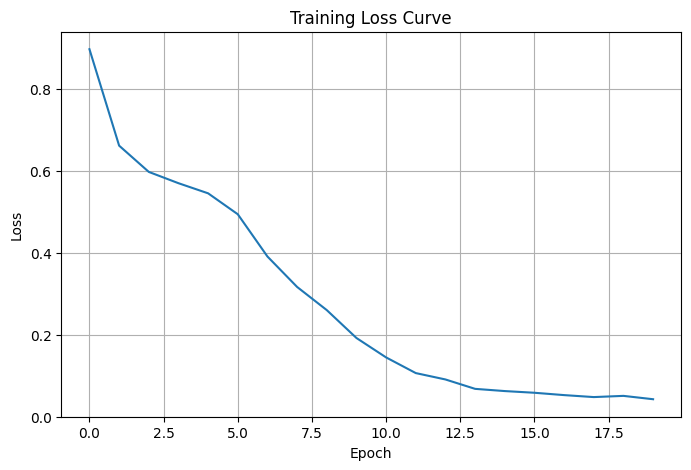

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(train_losses)

plt.title("Training Loss Curve")

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.grid(True)

plt.show()

In [ ]:
print(full_dataset.class_to_idx)

{'Mild': 0, 'Moderate': 1, 'No_DR': 2, 'Proliferate_DR': 3, 'Severe': 4}


In [ ]:
!pip install grad-cam seaborn scikit-learn

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    roc_curve,
    auc,
    roc_auc_score
)

from sklearn.preprocessing import label_binarize

from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image

In [ ]:
class_names = [
    "No_DR",
    "Mild",
    "Moderate",
    "Severe",
    "Proliferate_DR"
]

In [ ]:
all_preds = []
all_labels = []

model.eval()

with torch.no_grad():

    for images, labels in val_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        preds = torch.argmax(outputs, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

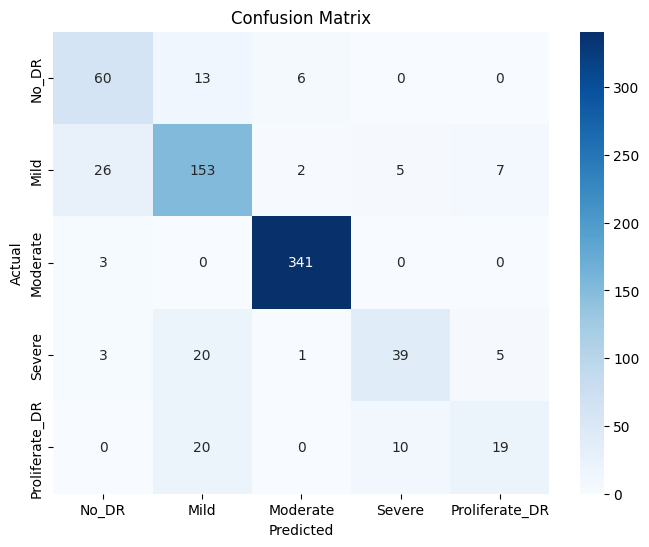

In [ ]:
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

In [ ]:
print(classification_report(
    all_labels,
    all_preds,
    target_names=class_names
))

                precision    recall  f1-score   support

         No_DR       0.65      0.76      0.70        79
          Mild       0.74      0.79      0.77       193
      Moderate       0.97      0.99      0.98       344
        Severe       0.72      0.57      0.64        68
Proliferate_DR       0.61      0.39      0.47        49

      accuracy                           0.83       733
     macro avg       0.74      0.70      0.71       733
  weighted avg       0.83      0.83      0.83       733



In [ ]:
all_probs = []
all_labels = []

model.eval()

with torch.no_grad():

    for images, labels in val_loader:

        images = images.to(device)

        outputs = model(images)

        probs = torch.softmax(outputs, dim=1)

        all_probs.extend(probs.cpu().numpy())
        all_labels.extend(labels.numpy())

In [ ]:
all_probs = np.array(all_probs)
all_labels = np.array(all_labels)

In [ ]:
y_bin = label_binarize(all_labels, classes=[0,1,2,3,4])

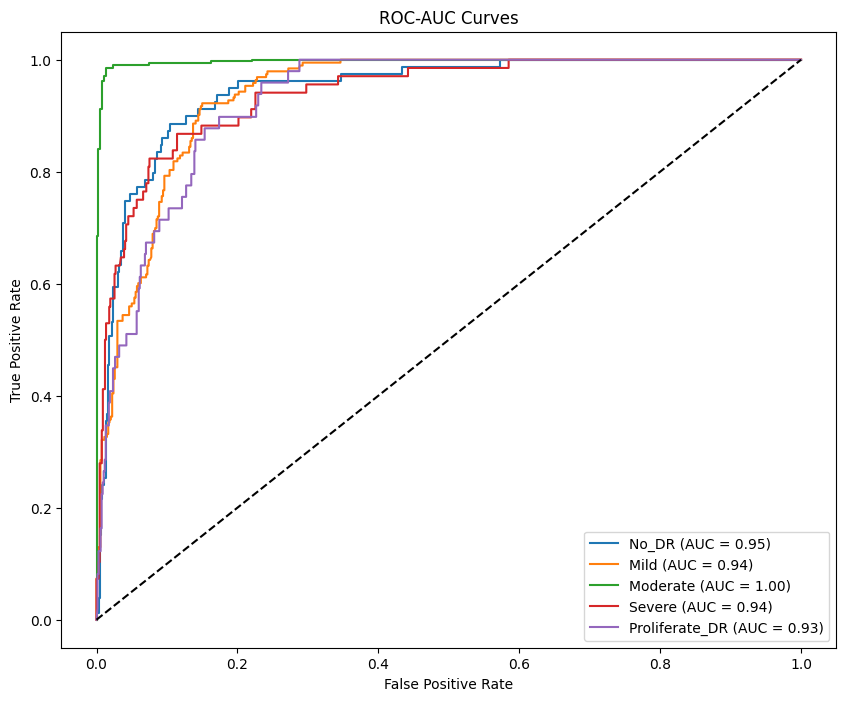

In [ ]:
plt.figure(figsize=(10,8))

for i in range(5):

    fpr, tpr, _ = roc_curve(y_bin[:, i], all_probs[:, i])

    roc_auc = auc(fpr, tpr)

    plt.plot(
        fpr,
        tpr,
        label=f"{class_names[i]} (AUC = {roc_auc:.2f})"
    )

plt.plot([0,1], [0,1], 'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC-AUC Curves")

plt.legend()
plt.show()

In [ ]:
overall_auc = roc_auc_score(
    y_bin,
    all_probs,
    multi_class='ovr'
)

print("Overall ROC-AUC:", overall_auc)

Overall ROC-AUC: 0.9501079027112747


In [ ]:
target_layers = [model.layers[-1].blocks[-1].norm1]

In [ ]:
images, labels = next(iter(val_loader))

input_tensor = images[0].unsqueeze(0).to(device)

rgb_img = images[0].permute(1,2,0).numpy()

rgb_img = (rgb_img - rgb_img.min()) / (rgb_img.max() - rgb_img.min())

In [ ]:
target_layers = [model.layers[-1].blocks[-1].norm1]

cam = GradCAM(
    model=model,
    target_layers=target_layers
)

In [ ]:
grayscale_cam = cam(
    input_tensor=input_tensor
)[0]

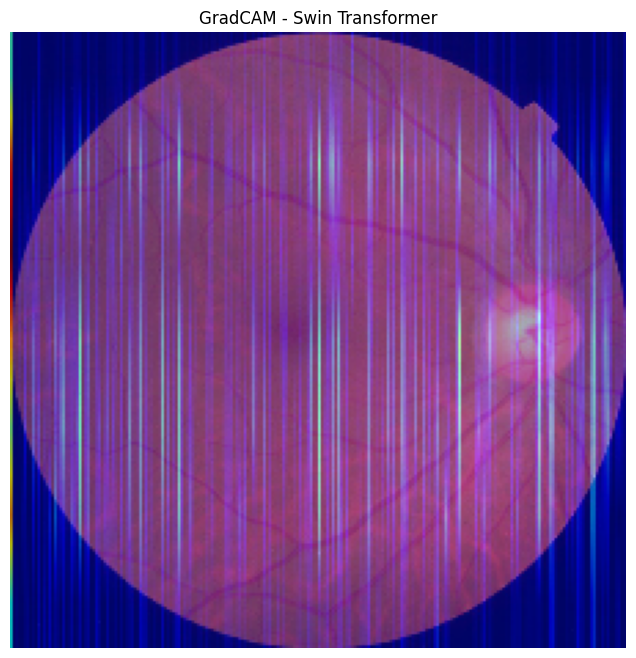

In [ ]:
visualization = show_cam_on_image(
    rgb_img,
    grayscale_cam,
    use_rgb=True
)

plt.figure(figsize=(8,8))
plt.imshow(visualization)
plt.title("GradCAM - Swin Transformer")
plt.axis('off')
plt.show()

In [ ]:
print(full_dataset.class_to_idx)

{'Mild': 0, 'Moderate': 1, 'No_DR': 2, 'Proliferate_DR': 3, 'Severe': 4}


In [ ]:
target_layers = [model.layers[-1].blocks[-1].norm1]

In [ ]:
cam = GradCAM(
    model=model,
    target_layers=target_layers
)

In [ ]:
correct_samples = {}
wrong_samples = {}

model.eval()

with torch.no_grad():

    for images, labels in val_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        preds = torch.argmax(outputs, dim=1)

        for i in range(len(labels)):

            true_label = labels[i].item()
            pred_label = preds[i].item()

            # Save one correct sample per class
            if true_label == pred_label:

                if true_label not in correct_samples:

                    correct_samples[true_label] = (
                        images[i].cpu(),
                        true_label,
                        pred_label
                    )

            # Save one wrong sample per class
            else:

                if true_label not in wrong_samples:

                    wrong_samples[true_label] = (
                        images[i].cpu(),
                        true_label,
                        pred_label
                    )

        # Stop when all classes collected
        if len(correct_samples) == 5 and len(wrong_samples) == 5:
            break

In [ ]:
def show_gradcam(sample, title):

    image_tensor, true_label, pred_label = sample

    input_tensor = image_tensor.unsqueeze(0).to(device)

    rgb_img = image_tensor.permute(1,2,0).numpy()

    rgb_img = (rgb_img - rgb_img.min()) / (rgb_img.max() - rgb_img.min())

    grayscale_cam = cam(input_tensor=input_tensor)[0]

    visualization = show_cam_on_image(
        rgb_img,
        grayscale_cam,
        use_rgb=True
    )

    plt.figure(figsize=(6,6))

    plt.imshow(visualization)

    plt.title(
        f"{title}\n"
        f"True: {class_names[true_label]} | "
        f"Pred: {class_names[pred_label]}"
    )

    plt.axis('off')

    plt.show()

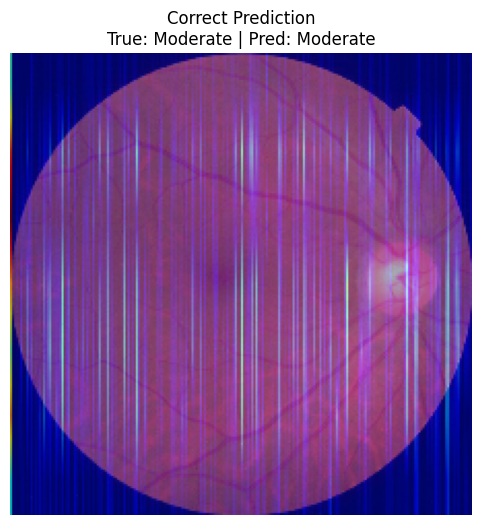

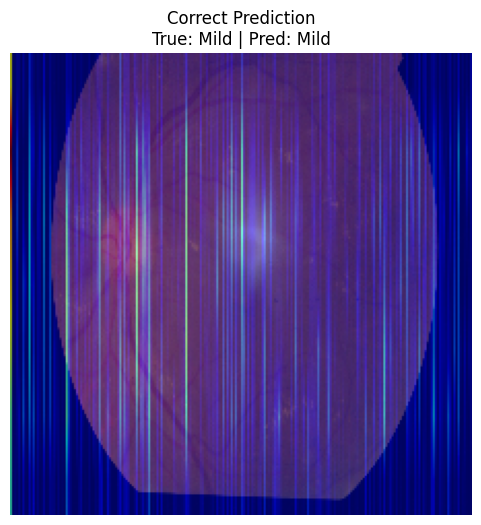

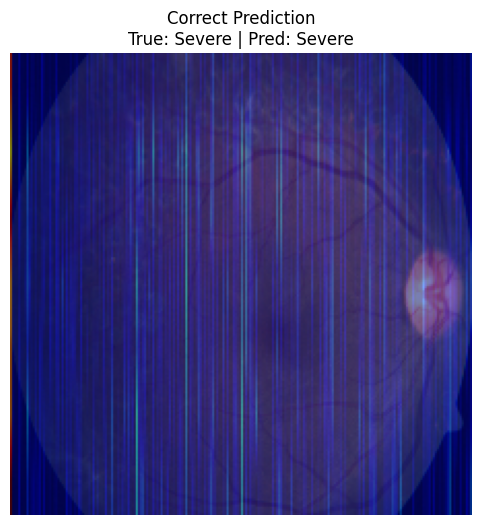

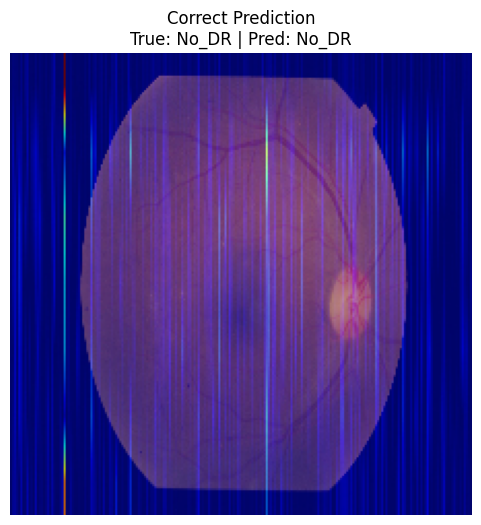

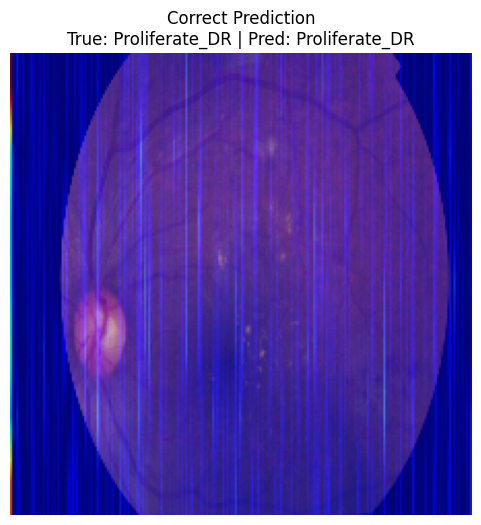

In [ ]:
for cls in correct_samples:

    show_gradcam(
        correct_samples[cls],
        title="Correct Prediction"
    )

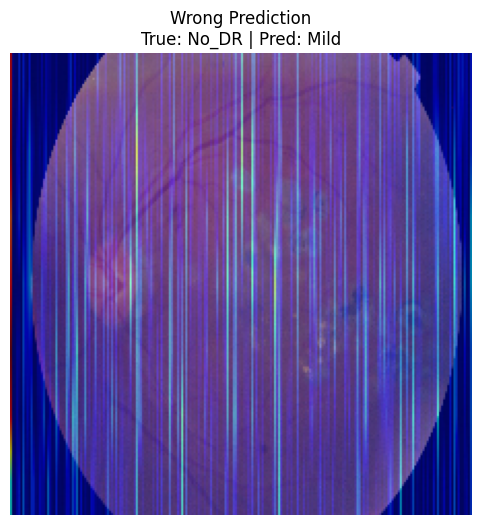

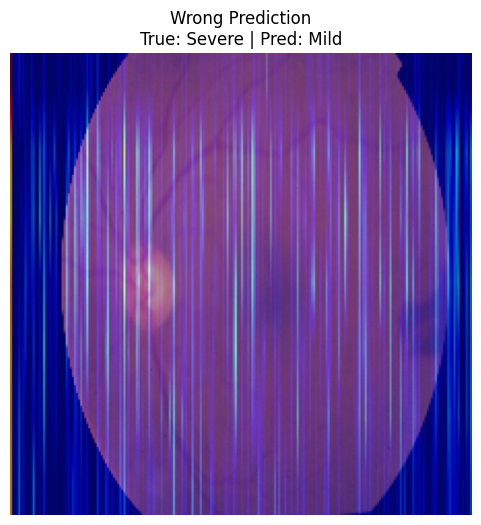

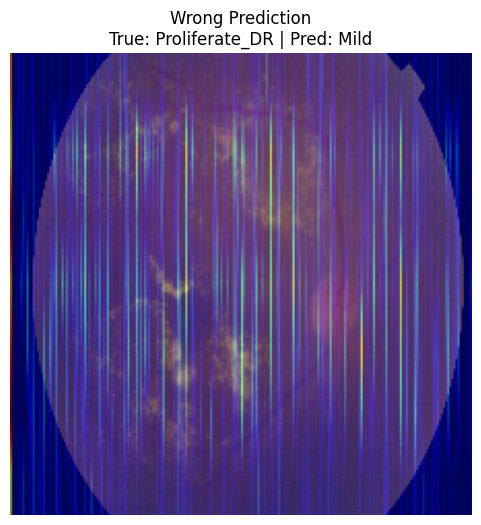

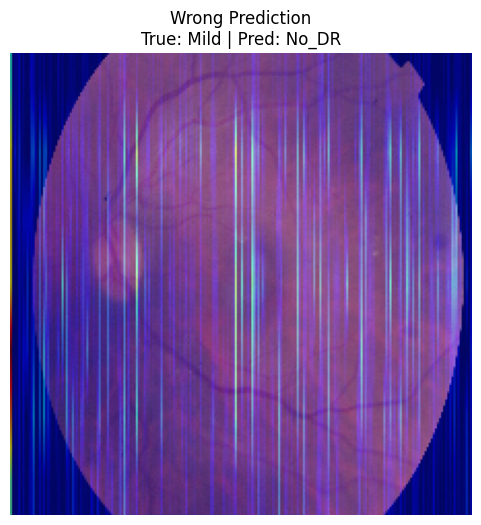

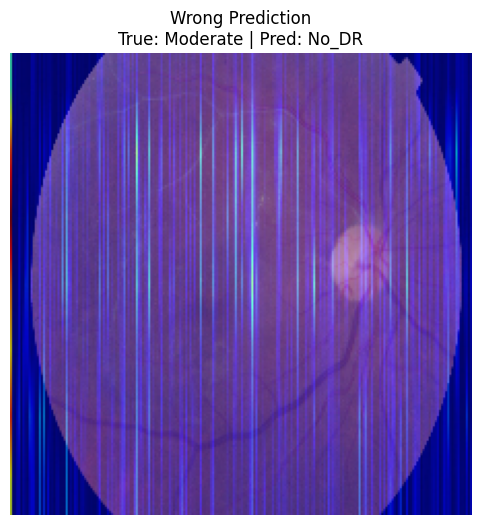

In [ ]:
for cls in wrong_samples:

    show_gradcam(
        wrong_samples[cls],
        title="Wrong Prediction"
    )

In [ ]:
checkpoint = {
    'model_state_dict': model.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'num_classes': 5
}

torch.save(
    checkpoint,
    "swin_checkpoint.pth"
)

print("Checkpoint saved!")

Checkpoint saved!


In [ ]:
torch.save(
    model.state_dict(),
    "swin_transformer_dr.pth"
)

print("Model saved successfully!")

Model saved successfully!
